In [11]:
import pandas as pd
import biom
from biom.util import biom_open
from biom.table import Table
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
from scipy.stats import kendalltau
from scipy.stats import spearmanr

mpl.rcParams['svg.fonttype'] = 'none'

In [12]:
tax_tbl = pd.read_csv("../data/qadabra/inputs/taxonomy_table.tsv", sep='\t')

tax_tbl = tax_tbl[tax_tbl['taxon_annotation'].isin(['hv-associated', 'bv-associated'])]
DA_list = tax_tbl['taxon_name'].tolist()
DA_list = [x.replace(" ", "_") for x in DA_list]

In [13]:
qadabra_results = pd.read_csv("../data/qadabra/outputs/qadabra_all_result.tsv", sep='\t')
qadabra_results

,feature_id,birdman differentials,deseq2 differentials,ancombc2 differentials,songbird differentials,aldex2 differentials,edger differentials,maaslin2 differentials,metagenomeseq differentials,deseq2 significant features,ancombc2 significant features,aldex2 significant features,edger significant features,maaslin2 significant features,metagenomeseq significant features,# of tools p > 0.05
0,Clostridium,-2.995478,-2.464678,-1.421208,-2.459621,-0.966786,-4.341331,-0.240808,-0.470330,ns,p<0.05,ns,ns,p<0.05,p<0.05,3.0
1,Haemophilus,-1.552010,-1.423296,0.060385,-1.362491,-0.704444,-1.863597,0.235522,-0.326075,ns,ns,ns,p<0.05,p<0.05,p<0.05,3.0
2,Gemella,2.736885,2.255466,1.136094,2.398971,2.114729,1.547069,2.250519,1.324646,p<0.05,p<0.05,p<0.05,p<0.05,p<0.05,p<0.05,6.0
3,Anaerovorax,1.152492,-0.760825,0.345996,0.680920,-0.451166,0.342111,0.225464,0.004006,ns,p<0.05,ns,ns,p<0.05,ns,2.0
4,Dermabacteraceae,2.307376,-1.224271,-0.233405,-0.170890,-0.630694,1.920524,0.035167,1.683783,ns,ns,ns,p<0.05,ns,p<0.05,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,Eggerthella,4.485369,5.351448,2.990553,4.033010,5.472722,3.384496,5.414771,4.293702,p<0.05,p<0.05,p<0.05,p<0.05,p<0.05,p<0.05,6.0
133,Ruminococcaceae,3.245682,4.072970,2.612640,3.035382,4.656728,2.368791,4.611933,3.580511,p<0.05,p<0.05,p<0.05,p<0.05,p<0.05,p<0.05,6.0
134,Fusobacterium,1.614527,1.584049,0.721917,1.396178,0.189662,1.714550,0.672943,0.903162,ns,p<0.05,ns,p<0.05,p<0.05,p<0.05,4.0
135,Campylobacter,0.993914,0.837658,0.381239,1.076860,0.463435,0.710209,0.979804,0.037460,ns,p<0.05,ns,ns,p<0.05,ns,2.0


In [14]:
tools = [
    'birdman differentials',
    'deseq2 differentials',
    'ancombc2 differentials',
    'songbird differentials',
    'aldex2 differentials',
    'edger differentials',
    'maaslin2 differentials'
]

for tool in tools:
    col = f"{tool} rank"
    
    # Get values
    vals = qadabra_results[tool]
    
    # Separate positive and negative
    pos_mask = vals > 0
    neg_mask = vals < 0
    
    # Rank positives: 1 = largest positive, 2 = next largest, etc.
    qadabra_results.loc[pos_mask, col] = vals[pos_mask].rank(method="dense", ascending=False)
    
    # Rank negatives: -1 = most negative, -2 = next most negative, etc.
    qadabra_results.loc[neg_mask, col] = -vals[neg_mask].rank(method="dense", ascending=True)
    
    # Leave 0 as 0 (or NaN if you'd prefer)
    qadabra_results.loc[~(pos_mask | neg_mask), col] = 0
    
qadabra_results

,feature_id,birdman differentials,deseq2 differentials,ancombc2 differentials,songbird differentials,aldex2 differentials,edger differentials,maaslin2 differentials,metagenomeseq differentials,deseq2 significant features,...,maaslin2 significant features,metagenomeseq significant features,# of tools p > 0.05,birdman differentials rank,deseq2 differentials rank,ancombc2 differentials rank,songbird differentials rank,aldex2 differentials rank,edger differentials rank,maaslin2 differentials rank
0,Clostridium,-2.995478,-2.464678,-1.421208,-2.459621,-0.966786,-4.341331,-0.240808,-0.470330,ns,...,p<0.05,p<0.05,3.0,-22.0,-7.0,-6.0,-6.0,-10.0,-9.0,-7.0
1,Haemophilus,-1.552010,-1.423296,0.060385,-1.362491,-0.704444,-1.863597,0.235522,-0.326075,ns,...,p<0.05,p<0.05,3.0,-30.0,-33.0,70.0,-26.0,-62.0,-34.0,61.0
2,Gemella,2.736885,2.255466,1.136094,2.398971,2.114729,1.547069,2.250519,1.324646,p<0.05,...,p<0.05,p<0.05,6.0,24.0,20.0,23.0,18.0,16.0,39.0,18.0
3,Anaerovorax,1.152492,-0.760825,0.345996,0.680920,-0.451166,0.342111,0.225464,0.004006,ns,...,p<0.05,ns,2.0,50.0,-91.0,59.0,44.0,-92.0,62.0,63.0
4,Dermabacteraceae,2.307376,-1.224271,-0.233405,-0.170890,-0.630694,1.920524,0.035167,1.683783,ns,...,ns,p<0.05,2.0,29.0,-77.0,-36.0,-76.0,-75.0,32.0,101.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,Eggerthella,4.485369,5.351448,2.990553,4.033010,5.472722,3.384496,5.414771,4.293702,p<0.05,...,p<0.05,p<0.05,6.0,2.0,4.0,6.0,1.0,6.0,4.0,6.0
133,Ruminococcaceae,3.245682,4.072970,2.612640,3.035382,4.656728,2.368791,4.611933,3.580511,p<0.05,...,p<0.05,p<0.05,6.0,15.0,10.0,8.0,12.0,7.0,19.0,7.0
134,Fusobacterium,1.614527,1.584049,0.721917,1.396178,0.189662,1.714550,0.672943,0.903162,ns,...,p<0.05,p<0.05,4.0,43.0,25.0,37.0,33.0,32.0,38.0,39.0
135,Campylobacter,0.993914,0.837658,0.381239,1.076860,0.463435,0.710209,0.979804,0.037460,ns,...,p<0.05,ns,2.0,56.0,31.0,55.0,36.0,28.0,54.0,33.0


In [15]:
# Positive-first DataFrame
qadabra_pos = qadabra_results.sort_values(
    by="birdman differentials rank", 
    ascending=True
)

# Keep only positive (>=1) ranks, reset index
qadabra_pos = qadabra_pos[qadabra_pos["birdman differentials rank"] > 0].reset_index(drop=True)

qadabra_pos.head(20)['feature_id'].tolist()


['Sneathia',
 'Eggerthella',
 'Megasphaera',
 'Aerococcus',
 'Gardnerella',
 'Parvimonas',
 'Atopobium',
 'Bacteroidetes',
 'Lachnospiraceae',
 'Proteobacteria',
 'Mycoplasmataceae',
 'Prevotellaceae',
 'Moryella',
 'Actinobaculum',
 'Ruminococcaceae',
 'Bulleidia',
 'Neisseriaceae',
 'Porphyromonas',
 'Peptostreptococcus',
 'Mobiluncus']

In [16]:
# Add in the birdman credible interval column to qadabra_results
birdman_results = pd.read_csv("../data/qadabra/outputs/birdman-differentials.tsv", sep='\t')
birdman_results = birdman_results.rename(columns={'feature id': 'feature_id'})
colname = "C(study_condition, Treatment('healthy'))[T.bacterial_vaginosis]_hdi"

qadabra_pos = qadabra_pos.merge(
    birdman_results[['feature_id', "C(study_condition, Treatment('healthy'))[T.bacterial_vaginosis]_hdi"]],
    on='feature_id', how='left'
)

qadabra_pos[['bot_val', 'top_val']] = (
    birdman_results[colname]
    .astype(str)
    .str.extract(r"\((-?\d*\.?\d+),\s*(-?\d*\.?\d+)\)")
    .astype(float)
)

qadabra_pos

,feature_id,birdman differentials,deseq2 differentials,ancombc2 differentials,songbird differentials,aldex2 differentials,edger differentials,maaslin2 differentials,metagenomeseq differentials,deseq2 significant features,...,birdman differentials rank,deseq2 differentials rank,ancombc2 differentials rank,songbird differentials rank,aldex2 differentials rank,edger differentials rank,maaslin2 differentials rank,"C(study_condition, Treatment('healthy'))[T.bacterial_vaginosis]_hdi",bot_val,top_val
0,Sneathia,4.628313,6.113807,3.906367,3.933646,6.220810,3.803558,6.199942,5.348541,p<0.05,...,1.0,2.0,2.0,2.0,5.0,1.0,4.0,"(3.76786, 5.48486)",-1.421460,2.974480
1,Eggerthella,4.485369,5.351448,2.990553,4.033010,5.472722,3.384496,5.414771,4.293702,p<0.05,...,2.0,4.0,6.0,1.0,6.0,4.0,6.0,"(3.79671, 5.22674)",-5.227550,-0.896522
2,Megasphaera,4.311080,5.380428,4.102960,3.920634,7.072688,2.754909,6.974283,5.525835,p<0.05,...,3.0,3.0,1.0,3.0,2.0,11.0,2.0,"(3.53737, 5.01418)",-4.800540,1.492020
3,Aerococcus,4.276853,4.901868,2.211971,3.600625,3.311700,3.653574,3.561557,3.320817,p<0.05,...,4.0,6.0,12.0,6.0,12.0,2.0,11.0,"(3.63741, 4.92381)",2.052970,3.523680
4,Gardnerella,4.020600,3.549332,0.952412,3.188653,3.826891,2.422762,4.486258,2.460165,p<0.05,...,5.0,12.0,29.0,8.0,10.0,18.0,8.0,"(3.53524, 4.54034)",0.091328,2.385490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,Enterobacter,0.119608,-1.358352,-0.693589,-0.643297,-0.655039,-1.668796,0.470496,-0.634062,ns,...,76.0,-58.0,-18.0,-63.0,-71.0,-36.0,45.0,"(-1.69156, 1.99823)",-4.644870,2.225080
76,Megamonas,0.101295,-1.491685,-2.206463,-0.425927,-0.584709,-1.481617,0.091414,0.351775,ns,...,77.0,-23.0,-4.0,-71.0,-79.0,-41.0,86.0,"(-3.02021, 3.47233)",-4.899120,7.093760
77,Enterobacteriaceae,0.098449,-1.343045,-0.118700,-0.614803,-0.707850,-1.249143,0.437742,-0.297786,ns,...,78.0,-66.0,-42.0,-64.0,-61.0,-44.0,46.0,"(-1.50122, 1.71762)",1.074120,2.962190
78,Streptococcus,0.055954,-0.472853,0.448413,0.033578,-0.208797,-1.930030,1.593526,0.092964,ns,...,79.0,-97.0,52.0,58.0,-98.0,-32.0,26.0,"(-0.857122, 0.963802)",-0.016349,1.538430


In [17]:
# Negative-first DataFrame
tool = 'birdman'

qadabra_neg = qadabra_results.sort_values(
    by=f"{tool} differentials rank", 
    ascending=False
)

# Keep only negative (<=-1) ranks, reset index
qadabra_neg = qadabra_neg[qadabra_neg[f"{tool} differentials rank"] < 0].reset_index(drop=True)

qadabra_neg.head(20)['feature_id'].tolist()


['Lactococcus',
 'Flavobacteriaceae',
 'Lactobacillus_vaginalis',
 'Parabacteroides',
 'Incertae',
 'Lactobacillus_crispatus',
 'Dermabacter',
 'Rothia',
 'Janthinobacterium',
 'Enhydrobacter',
 'Pasteurella',
 'Sphingomonas',
 'Novosphingobium',
 'Methylobacterium',
 'Bilophila',
 'Neisseria',
 'Lactobacillus_jensenii',
 'Duganella',
 'Bacillus',
 'Janibacter']

In [18]:
birdman_results = pd.read_csv("../data/qadabra/outputs/birdman-differentials.tsv", sep='\t')
birdman_results = birdman_results.rename(columns={'feature id': 'feature_id'})
colname = "C(study_condition, Treatment('healthy'))[T.bacterial_vaginosis]_hdi"
qadabra_neg = qadabra_neg.merge(
    birdman_results[['feature_id', colname]],
    on='feature_id', how='left'
)

qadabra_neg[['bot_val', 'top_val']] = (
    birdman_results[colname]
    .astype(str)
    .str.extract(r"\((-?\d*\.?\d+),\s*(-?\d*\.?\d+)\)")
    .astype(float)
)

qadabra_neg

,feature_id,birdman differentials,deseq2 differentials,ancombc2 differentials,songbird differentials,aldex2 differentials,edger differentials,maaslin2 differentials,metagenomeseq differentials,deseq2 significant features,...,birdman differentials rank,deseq2 differentials rank,ancombc2 differentials rank,songbird differentials rank,aldex2 differentials rank,edger differentials rank,maaslin2 differentials rank,"C(study_condition, Treatment('healthy'))[T.bacterial_vaginosis]_hdi",bot_val,top_val
0,Lactococcus,-6.266470,-1.942857,0.000000,-2.307867,-1.070632,-6.529801,-0.192782,-2.562310,ns,...,-1.0,-9.0,0.0,-8.0,-9.0,-2.0,-8.0,"(-11.3355, -1.95165)",-1.421460,2.974480
1,Flavobacteriaceae,-5.437357,-1.661870,0.000000,-2.008581,-0.887084,-6.147826,0.291703,0.061704,ns,...,-2.0,-14.0,0.0,-10.0,-11.0,-5.0,54.0,"(-12.1571, -0.700337)",-5.227550,-0.896522
2,Lactobacillus_vaginalis,-5.244766,-6.124335,-1.049209,-4.581524,-3.345619,-6.255933,-1.907038,-2.576327,p<0.05,...,-3.0,-3.0,-11.0,-2.0,-4.0,-4.0,-4.0,"(-6.48623, -3.89892)",-4.800540,1.492020
3,Parabacteroides,-4.976756,-1.725557,0.000000,-1.968762,-0.729924,-5.011382,-0.058532,-0.245198,ns,...,-4.0,-12.0,0.0,-11.0,-49.0,-7.0,-11.0,"(-11.2476, 0.906628)",2.052970,3.523680
4,Incertae,-4.677474,-1.440945,0.000000,-1.531515,-0.875686,-3.349794,0.121346,-0.047349,ns,...,-5.0,-28.0,0.0,-19.0,-12.0,-17.0,81.0,"(-9.77816, 0.183209)",0.091328,2.385490
5,Lactobacillus_crispatus,-4.641572,-7.458656,-4.351390,-4.978542,-6.378480,-5.210989,-5.639758,-5.993908,p<0.05,...,-6.0,-1.0,-1.0,-1.0,-1.0,-6.0,-1.0,"(-5.24647, -4.05664)",-2.029910,7.084330
6,Dermabacter,-4.428865,-1.415496,0.000000,-1.415053,-0.787620,-3.287171,0.141527,-0.048019,ns,...,-7.0,-34.0,0.0,-23.0,-21.0,-18.0,78.0,"(-10.5175, 0.675374)",-4.191590,4.238130
7,Rothia,-4.386671,-1.411977,0.000000,-2.515972,-0.822736,-6.793719,0.168475,-0.518068,ns,...,-8.0,-35.0,0.0,-5.0,-16.0,-1.0,71.0,"(-11.964, 3.48492)",-1.657060,2.449720
8,Janthinobacterium,-4.276169,-1.428293,0.000000,-1.458661,-0.796621,-3.800384,0.043762,-0.060560,ns,...,-9.0,-30.0,0.0,-21.0,-17.0,-13.0,96.0,"(-10.3938, 1.53528)",-0.802189,3.249630
9,Enhydrobacter,-4.272937,-1.402780,0.000000,-1.386576,-0.746568,-2.213160,-0.024114,-0.053755,ns,...,-10.0,-37.0,0.0,-24.0,-42.0,-30.0,-18.0,"(-10.0317, 0.777136)",-2.902830,2.645590


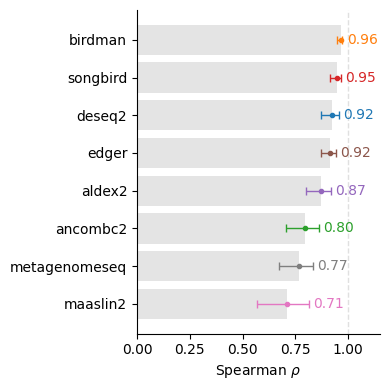

In [19]:
tools = ['birdman','deseq2','ancombc2','songbird','aldex2','edger','maaslin2','metagenomeseq','corncob']
tool_colors = {
    'birdman': '#ff7f0e',
    'deseq2': '#1f77b4',
    'ancombc2': '#2ca02c',
    'songbird': '#d62728',
    'aldex2': '#9467bd',
    'edger': '#8c564b',
    'maaslin2': '#e377c2',
    'metagenomeseq': '#7f7f7f',
    'corncob': '#bcbd22'
}

# Collect differentials (raw values, not ranks)
diffs = {}
for t in tools:
    col = f"{t} differentials"
    if col not in qadabra_results.columns:
        continue
    sub = qadabra_results[['feature_id', col]].replace([np.inf, -np.inf], np.nan).dropna()
    diffs[t] = sub.set_index('feature_id')[col]

# Combine into DataFrame (rows = features, cols = tools)
diff_df = pd.concat(diffs.values(), axis=1, keys=diffs.keys())

# Consensus = mean across tools
consensus_diff = diff_df.mean(axis=1)

# --- Compute correlations + bootstrap CIs ---
scores = {}
n_boot = 1000
rng = np.random.default_rng(42)  # reproducibility

for t in diff_df.columns:
    vals_tool = diff_df[t].dropna()
    vals_cons = consensus_diff.loc[vals_tool.index]

    # Full-sample rho
    rho, _ = spearmanr(vals_tool, vals_cons)

    # Bootstrap
    boot_rhos = []
    vals = np.column_stack([vals_tool.values, vals_cons.values])
    n = len(vals)
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)  # resample indices
        rho_b, _ = spearmanr(vals[idx,0], vals[idx,1])
        boot_rhos.append(rho_b)
    ci_low, ci_high = np.percentile(boot_rhos, [2.5, 97.5])

    scores[t] = (rho, ci_low, ci_high)

# Convert to DataFrame
score_df = pd.DataFrame(scores, index=['rho','ci_low','ci_high']).T
score_df = score_df.sort_values("rho", ascending=True)

# --- Plot dot+bar with error bars + text annotations ---
os.makedirs("../figures", exist_ok=True)
fig, ax = plt.subplots(figsize=(4,4))

# Grey bars for background
ax.barh(score_df.index, score_df['rho'], color="lightgrey", alpha=0.6)

# Colored dots + error bars
for tool in score_df.index:
    rho = score_df.loc[tool, 'rho']
    ci_low = score_df.loc[tool, 'ci_low']
    ci_high = score_df.loc[tool, 'ci_high']
    
    # Dot + error bar (force visible caps)
    ax.errorbar(
        rho, tool,
        xerr=[[max(rho-ci_low, 1e-4)], [max(ci_high-rho, 1e-4)]],  # force min error
        fmt='o',
        color=tool_colors[tool],
        markersize=3,
        capsize=3,      # make cap visible
        capthick=1,   # thicker caps
        lw=1
    )
    
    # Annotate rho value
    ax.text(
        ci_high + 0.02, tool, f"{rho:.2f}",
        va='center', ha='left', fontsize=10, color=tool_colors[tool]
    )


# Grey vertical dashed reference line at rho = 1.0
ax.axvline(
    x=1.0,
    color="lightgrey",
    linestyle="--",
    linewidth=1,
    alpha=0.7,
    zorder=0
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlabel(r"Spearman $\rho$")
ax.set_ylabel("")
# ax.set_title("Correlation with Qadabra consensus")
ax.set_xlim(0, 1.15)  # add space for annotation text

plt.tight_layout()

plt.savefig("../figures/qadabra/differentials_vs_consensus_dotbar_ci_text.png", dpi=600, bbox_inches="tight")
# plt.savefig("../figures/differentials_vs_consensus_dotbar_ci_text.svg", format="svg", bbox_inches="tight")


In [20]:
# Convert to DataFrame
score_df = pd.DataFrame(scores, index=['rho','ci_low','ci_high']).T
score_df = score_df.sort_values("rho", ascending=True)

# --- Print results for inspection ---
print("\nSpearman correlations with 95% bootstrap CIs:\n")
for tool in score_df.index:
    rho = score_df.loc[tool, 'rho']
    ci_low = score_df.loc[tool, 'ci_low']
    ci_high = score_df.loc[tool, 'ci_high']
    print(f"{tool:10s}:  ρ = {rho:.3f}  (95% CI: {ci_low:.3f} – {ci_high:.3f})")


Spearman correlations with 95% bootstrap CIs:

maaslin2  :  ρ = 0.708  (95% CI: 0.568 – 0.815)
metagenomeseq:  ρ = 0.768  (95% CI: 0.672 – 0.835)
ancombc2  :  ρ = 0.795  (95% CI: 0.705 – 0.860)
aldex2    :  ρ = 0.870  (95% CI: 0.799 – 0.918)
edger     :  ρ = 0.916  (95% CI: 0.872 – 0.944)
deseq2    :  ρ = 0.922  (95% CI: 0.871 – 0.955)
songbird  :  ρ = 0.947  (95% CI: 0.912 – 0.966)
birdman   :  ρ = 0.964  (95% CI: 0.948 – 0.972)
